# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos.
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas.
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
titanic = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



- Las variables numéricas son: 'PassangerId', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin'.
- Las variables categóricas son: 'Survived', 'Pclass', 'Name','Sex', 'Embarked'.

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


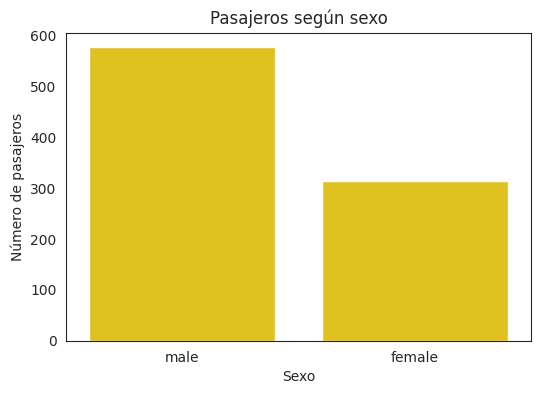

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


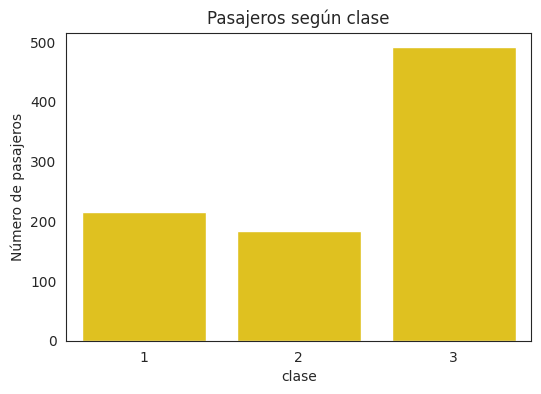

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="gold")

plt.xlabel("clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()


**¿Qué clase contiene más pasajeros?**

La tercera clase es la que más pasajeros tenía.

**¿La muestra esta balanceada en las tres clases?**

No, hay una clara desigualdad, la tercera clase contiene más pasajeros.

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


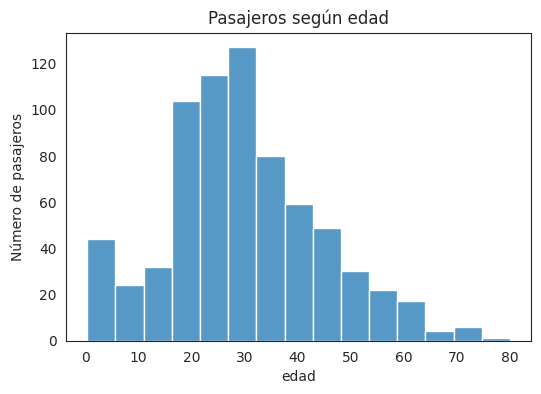

In [9]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=15)

plt.xlabel("edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()
# sns.histplot(...)


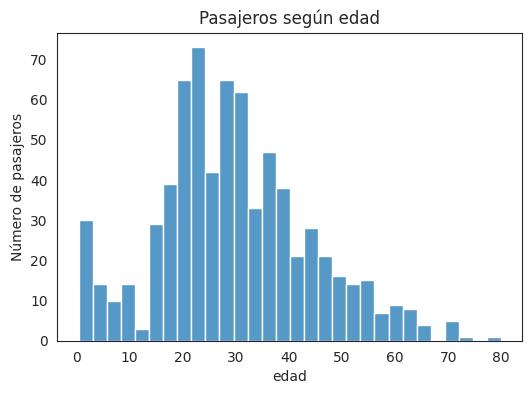

In [10]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=30)

#plt.xticks(np.arange())
plt.xlabel("edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()

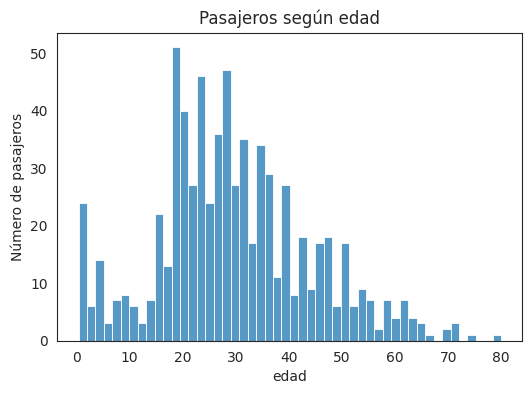

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=50, )

plt.xlabel("edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()

**¿Qué edades son más frecuentes?**

Las edades más frecuentes son la gente entre 18 a 30 años de edad, es decir, personas jóvenes.

**¿La distribución parece simétrica?**

No, es bastante asimétrica, claramente cargada hacia personas menores a 30 años.

**¿El número de bins cambia su interpretación?**

Como apreciación general no tanto, pues se entiende en los 3 gráficos que había más gente menor de 30 años, sin embargo, al tener más bins se tiene una mejor idea de rangos más acotados. Se vé en el primer gráfico que hay más gente de alrededor de 30 años, pero con los otros 2 uno se da cuenta que había más gente entre 18 y 20 años.

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


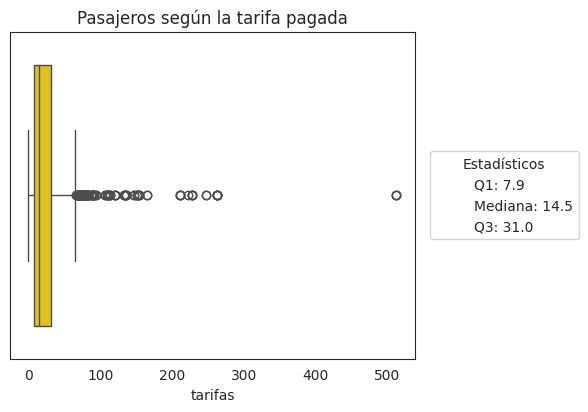

In [12]:
q1 = np.percentile(titanic["Fare"], 25)
mediana = np.median(titanic["Fare"])
q3 = np.percentile(titanic["Fare"], 75)

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=titanic["Fare"], ax=ax, color="gold")

leyenda_elementos = [
    mpatches.Patch(color="none", label=f"Q1: {q1:.1f}"),
    mpatches.Patch(color="none", label=f"Mediana: {mediana:.1f}"),
    mpatches.Patch(color="none", label=f"Q3: {q3:.1f}"),
]

ax.legend(
    handles=leyenda_elementos,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Estadísticos",
)

plt.tight_layout()

plt.xlabel("tarifas")
#plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según la tarifa pagada")

plt.show()


**¿La distribución es simétrica?**

No, para nada es simétrica, la mediana no está ni cerca de la mitad del valor de la tarifa más alta.

**¿Existen tarifas muy superiores al resto?**

Sí, hay una que supera los 500 (no sé si son dólares o libras o alguna otra moneda), mientras que el cuartil 3 apenas llega a los 31.

**¿Qué podría significar esto?**

Significa que hubo mucha gente que no pagó tanto, lo más probable es que como se vió antes la tercera clase era mayoritaria, y esa gente es la que menos paga. Además debe haber una clara desigualdad social entre los pasajeros.

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [13]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


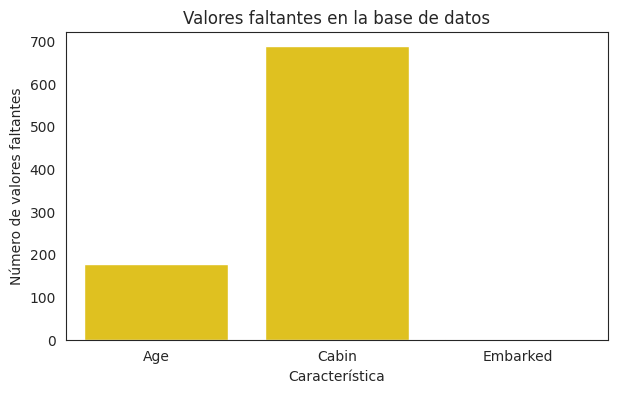

In [14]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [15]:
media_age=np.mean(titanic["Age"])
print(media_age)

29.69911764705882


In [16]:
df = pd.DataFrame({"valores": titanic["Age"]})

mediana = df["valores"].median()
print(mediana)

28.0


**Son similares?**

Sí, bastante parecidos.

**Es la media una buena representación de una edad típica?**

No, pues como faltan varios datos no se puede saber si esos datos de edad estarán cerca de la media.

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


No me parece tan razonable, solamente por la gran cantidad de datos que son, casi 200 datos no son poca cosa, afectarían enormemente a la distribución de la muestra. Lo que se podría hacer es ver la tarifa y/o la clase, también teniendo las edades medias por clase se podría hacer una mejor agrupación de estas personas y tratar de distribuir de mejor manera los datois faltantes.

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


Los datos faltantes en la columna `Cabin` no deberían intentarse de rellenar, pues no hay alguna manera de saberlo o intuirlo con otros datos, los datos en `Age` al menos podrían aproximarse con la media, no es buena aproximación, pero era algo. Acá en cambio no tenemos nada, no los eliminaría, solamente no los usaría para sacar conclusiones, pues son muy pocos datos. Lo cual puede ser malo pues saber la cabina sería útil si se tuviera un mapa del barco y saber si el lugar estaba, por ejemplo, cerca de los botes de evacuación. Aunque eso tampoco es una información muy relevante pues no necesariamente debían encontrarse en ese lugar en el momento del hundimiento.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


En este caso si se podrían eliminar esos 2 datos sin afectar a la muestra de forma significativa, a diferencia de `Cabin`que tenía demasiados datos vacíos, acá 2 datos menos frente a los cientos que hay no cambiarán en nada la estadística.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


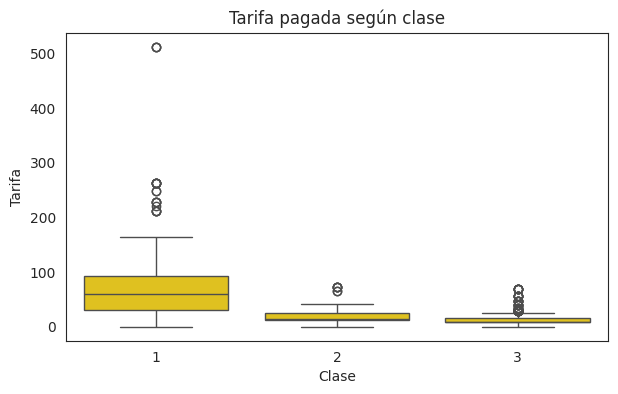

In [17]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?

Sí, existe cierta correlación, aunque no al 100% pues los datos igual se distribuyen en un gran rango sin importar la clase.
- Hay dispersión dentro de cada clase?

Solo la primera clase contiene gran dispersión las otras 2 clases estan más acotadas, aunque tienen unos valores extremos.
- Existen valores extremos?

Sí, en las 3 clases hay valores extremos, sobretodo en la primera y la tercera clase.
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?

No, contienen información relacionada, pero no igual, de hecho tener las 2 da un mejor panorama de la situación, se ve claramente que hay diferencias de precios, quizás pueda ser el lugar de embarque o alguna otra característica no solo la clase determianaba el precio del ticket.


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


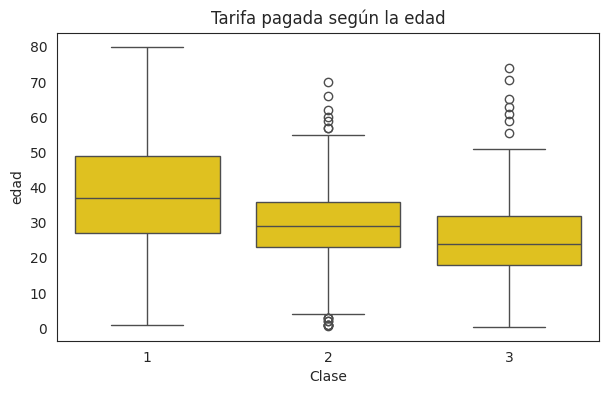

In [18]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Age", color='gold')

plt.xlabel("Clase")
plt.ylabel("edad")
plt.title("Tarifa pagada según la edad")

plt.show()


**Los pasajeros tienen edades similares en todas las clases?**

No, se ve claramente una tendencia a que los pasajeros de tercera clase solían ser más jóvenes y los de primera más mayores.

**Qué diferencias observa?**

Aparte de la diferencia sobre las tendencias dichas anteriormente, llama la atención los valores extremos de las clases 2 y 3, que no se ven en la primera clase. Lo que dice que la primera clase era bien homogénea en las edades, en cambio las otras dos tienden a centrarse en un rango etario más reducido.

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [19]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1

titanic["Familia"]

,Familia
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


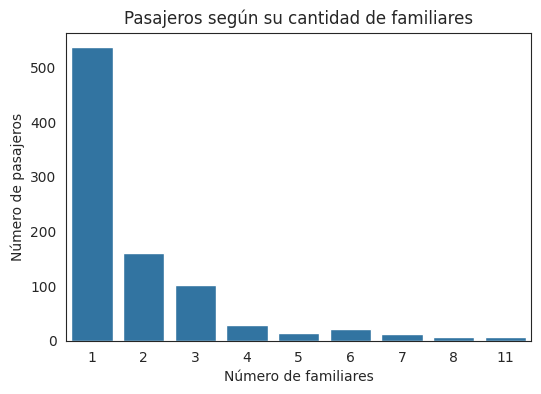

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Familia")

plt.xlabel("Número de familiares")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según su cantidad de familiares")

plt.show()

**La mayoría de los pasajeros viajaba sola o acompañada?**

La mayoría viajaba sola.

**Hay grupos familiares muy grandes?**

Sí, de hasta 11 miembros del grupo familiar.

**Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?**

Cambiaría la interpretación referente al tamaño del grupo familiar, sin embargo se seguiría notando que la mayor parte de los pasajeros viajaba solo.


# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


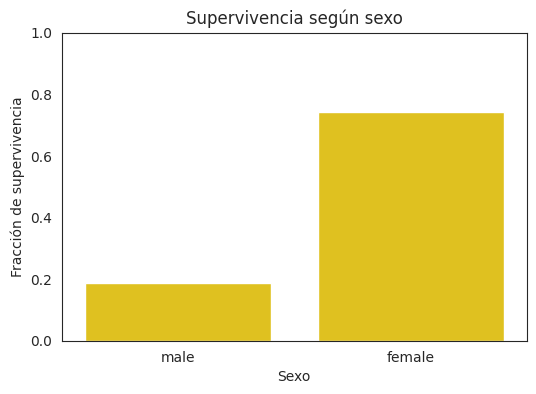

In [21]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?

No, es mucho mayor la fracción de supervivencia de las mujeres frente a los hombres.
- Podemos concluir a partir de este gráfico por qué existe la diferencia?

No podemos concluir esa información, solo sabemos que las mujeres sobrevivieron más, pero no hay nada que nos diga el porqué.

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


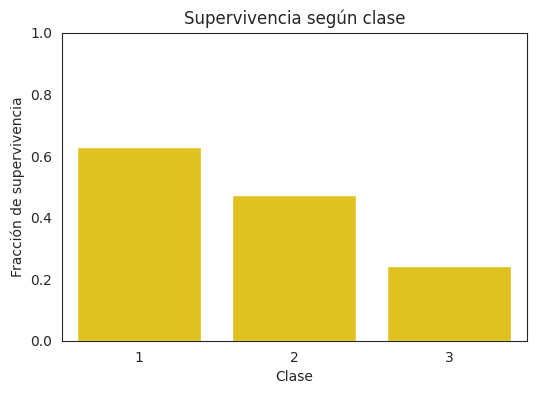

In [22]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='gold')

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()


**Hay diferencias entre las tres clases?**

Sí que las hay, se nota claramente que la clase 1 tuvo mucho mejor ratio de supervivencia que la clase 3.

**Existe una tendencia?**

Sí, al aumentar de clase la fracción de personas sobrevivientes es mayor.

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


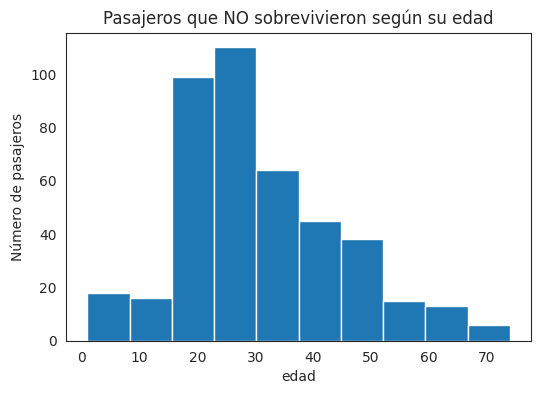

In [23]:
df=pd.DataFrame(titanic)
edades_0 = df.loc[df["Survived"] == 0, "Age"].to_numpy()
edades_1 = df.loc[df["Survived"] == 1, "Age"].to_numpy()
plt.figure(figsize=(6,4))

plt.hist(edades_0)

plt.xlabel("edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros que NO sobrevivieron según su edad")

plt.show()



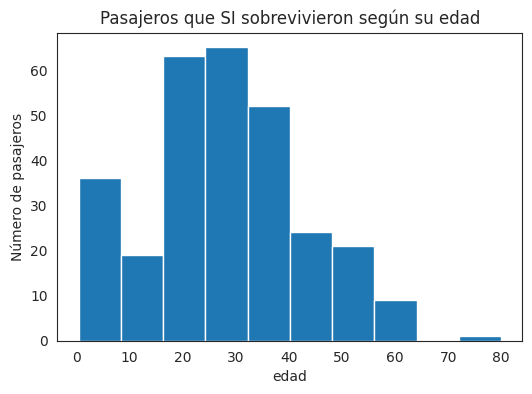

In [24]:
plt.figure(figsize=(6,4))

plt.hist(edades_1)

plt.xlabel("edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros que SI sobrevivieron según su edad")

plt.show()

**La edad parece estar asociada con supervivencia? Hay algún grupo de edad que llame particularmente su atención?**

La edad no parece estar correlacionada con la supervivencia en general, únicamente el grupo de los niños si parece existir correlación, pues entre los 0 a 18 años si se ve que hubo mayor supervivencia.

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


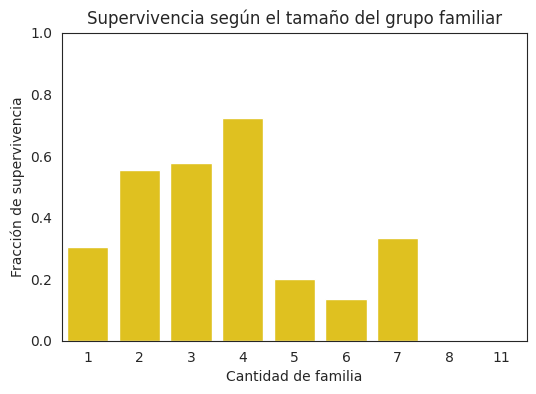

In [25]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='gold')

plt.xlabel("Cantidad de familia")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según el tamaño del grupo familiar")
plt.ylim(0,1)

plt.show()


**Viajar solo parece favorable o desfavorable?**

AL parecer viajar solo si es favorable, pues la fracción de supervivencia de personas que viajaban con familia es mayor que la de gente que viajaba solo.

**La relación parece simple?**

No diría que simple, pues si la familia era bien grande, mayor que 4, no hay buena taza de supervivencia, es complicada y no una buena variable para tomarse en cuenta por sí misma, quizás habría que ver a que clase pertenecian esas familias.

**Qué ocurre con los grupos familiares grandes?**

Se ve que los grupos muy grandes de 8 u 11 personas no sobreviven, aunque los de 7 sí sobrevivieron, como mencioné antes hay que ver mejor la situación de esas familias numerosas.

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


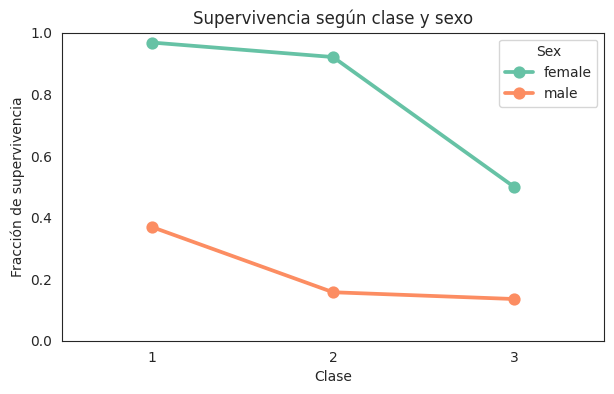

In [26]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?

Más o menos sí, ambos diminuyen con la clase, aunque las mujeres de una manera más abrupta.
- Qué información se perdía cuando mirábamos solamente `Pclass`?

Se perdía la diferencia entre hombres y mujeres
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?

La tercera clase se ve muy desfavorecido, seas hombre o mujer la taza de supervivencia era muy baja. En cambio si eras de primera clase y mujer, tenías casi garantizada la supervivencia.



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [27]:
# Complete el código

titanic["Persona"] = np.where(
    titanic["Age"] < 16,
    "niño/a",
    np.where(
        titanic["Sex"] == "female",
        "mujer",
        "hombre"))

# Revise el resultado
titanic["Persona"].value_counts()


,count
Persona,
hombre,537
mujer,271
niño/a,83


**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


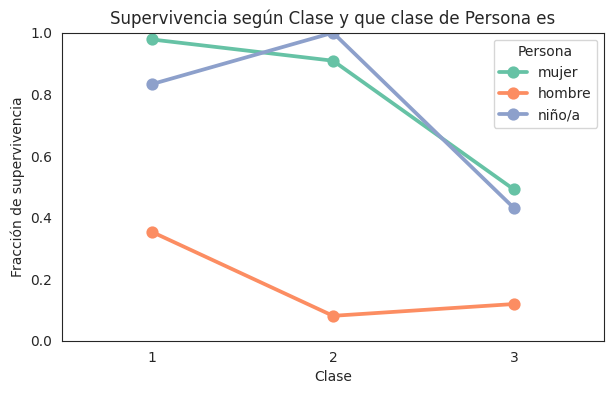

In [28]:
# Escriba aquí su código
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según Clase y que clase de Persona es")
plt.ylim(0,1)

plt.show()

**Los niños presentan el mismo patrón que los adultos?**

Presentan un patron muy parecido al de las mujeres.

**La clase sigue siendo importante dentro de cada grupo?**

Totalmente, si eras de tercera clase tus posibilidades se reducían muchísimo, sin importar si eras adulto, niño, hombre o mujer.

**Qué combinación de características parece asociarse con la mayor supervivencia?**

Ser mujer o niño, y ser de clase alta, si se combinan esas 2 cosas las posibilidades aumentan muchísimo.

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


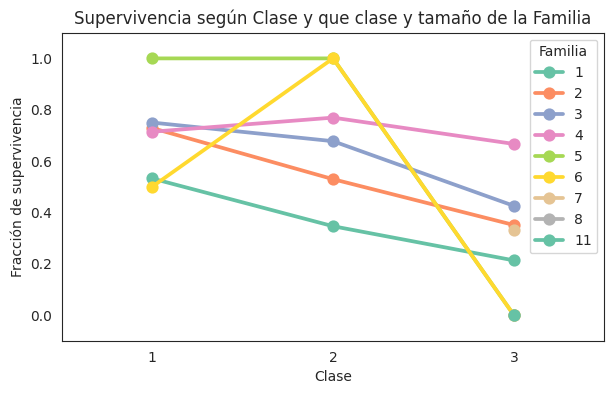

In [29]:
# Pregunta:
"¿Solo el tamaño de la familia aumenta la supervivencia? ¿Afecta también la clase?"
# Código:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Familia",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según Clase y que clase y tamaño de la Familia")
plt.ylim(-0.1,1.1)

plt.show()

**¿Solo el tamaño de la familia aumenta la supervivencia? ¿Afecta también la clase?**

Efectivamente el tamaño de la familia si aumenta la supervivencia, hasta los 5 miembros, luego de eso la tendencia no es clara, la clase como siempre a mayor clase mejor taza de supervivencia. Para 6, 7, 8 y 11 miembros familiares los datos no dicen mucho, pues para los 3 últimos solo hay datos de tercera clase, y para 6 la línea sigue una forma rara.

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


**¿Quiénes eran los pasajeros del Titanic?**

Los pasajeros del titanic eran personas de todo tipo, la gran mayoría eran hombres (537/891) , personas jóvenes de entre 18 a 30 años y gente de tercera clase. Muchos viajaban solos, aunque si habían familias más numerosas de hasta 11 miembros.

**¿Qué características estaban asociadas con la supervivencia?**

Lo principal era el sexo y la edad, las mujeres y los niños tenían una supervivencia mucho mayor, sobre 0.8 para primera y segunda clase, y alrededor de 0.5 para tercera. Los hombres solo tenían una taza de supervivencia de 0.4 para la primera clase, si eran de las otras 2 era casi imposible sobrevivir. Igualmente ir acompañado aumentaba la taza de supervivencia, aunque no tan consistentemente.

**Qué relaciones cambiaron al considerar varias características al mismo tiempo?**

Ninguna cambió tan significativamente como la Clase, uno pensaría que de por sí ser de una clase alta te daría más chances de supervivencia, pero al comparar con el sexo se nota que ni los hombres de alta clase tenían buena chance de supervivencia. Lo que más importaba era el sexo o ser niño.

**¿Encontró características que contienen información relacionada?**

Sí, el más destacado es la Clase y la Tarifa pagada, que tienen una clara relación, aunque sorprendentemente no eran lo mismo, pues había un gran rango de precios en cada clase.

**¿Qué resultado le pareció más inesperado?**

El resultado más inesperado para mí fue lo relacionado al dato de Familia, observar que efectivamente ir acompañado aumentaba la supervivencia en las 3 clases fue interesante. Lo que se me ocurre es que esas familias deben estar compuestas por una esposa e hijos, por lo que, de ser así los padres y esposos se preocuparon por su familia antes que todo, como en la película "Mujeres y niños primero".

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


El pasajero típico que sobrevivió es el de una mujer o un niño perteneciente a la primera o segunda clase, que además seguramente viajaba acompañada/o. Me baso en los últimos gráficos de puntos para afirmar esto, pues estos muestran claramente una tendencia a la baja con las clases, e ilustran que los hombres, ya adultos no tenían casi ninguna chance, a menos que pertenecieran a la primera clase.